# Koo-IntGrad + MPRA-LegNet attributions — seqlets + mech/func

Cell 1: load attribution H5s (HepG2 + K562 for both sources), the shared library CSV, and `tangermeme.seqlet.recursive_seqlets` / `tfmodisco_seqlets`.

Cell 2: per-cell-line seqlets (separate calls) + cossim(HepG2, K562) vs log2FC(HepG2−K562) scatter (mech/func space). No t-SNE, no clustering.


In [105]:
import numpy as np
import pandas as pd
import h5py
from pathlib import Path

from tangermeme.seqlet import recursive_seqlets, tfmodisco_seqlets

ATTR = Path('/grid/koo/home/pmantill/projects/kcee-ui/data/attributions')
LIB_CSV = ATTR / 'manifest.csv'

# (model_dir, attribution method) per source key.
SOURCES = {
    'koo_intgrad':     (ATTR / 'koo_standardtorch', 'intgrad'),
    'koo_deeplift':    (ATTR / 'koo_standardtorch', 'deeplift'),
    'legnet_intgrad':  (ATTR / 'legnet_ensemble',   'intgrad'),
    'legnet_deeplift': (ATTR / 'legnet_ensemble',   'deeplift'),
}
CELLS = ['HepG2', 'K562']

def load_attr(src_dir, ct, method):
    with h5py.File(src_dir / f'{ct}_{method}.h5') as f:
        return f['attr'][:], f['predictions'][:]

attr = {}
pred = {}
for src, (d, method) in SOURCES.items():
    for ct in CELLS:
        a, p = load_attr(d, ct, method)
        attr[(src, ct)] = a
        pred[(src, ct)] = p
        print(f'{src:18s} {ct:6s} attr={a.shape} pred={p.shape}')

library = pd.read_csv(LIB_CSV)
print('library:', library.shape, 'cols:', list(library.columns)[:8], '...')


koo_intgrad        HepG2  attr=(56975, 4, 200) pred=(56975,)
koo_intgrad        K562   attr=(56975, 4, 200) pred=(56975,)
koo_deeplift       HepG2  attr=(56975, 4, 200) pred=(56975,)
koo_deeplift       K562   attr=(56975, 4, 200) pred=(56975,)
legnet_intgrad     HepG2  attr=(56975, 4, 200) pred=(56975,)
legnet_intgrad     K562   attr=(56975, 4, 200) pred=(56975,)
legnet_deeplift    HepG2  attr=(56975, 4, 200) pred=(56975,)
legnet_deeplift    K562   attr=(56975, 4, 200) pred=(56975,)
library: (56975, 11) cols: ['csv_row', 'name', 'category', 'chr_hg38', 'start_hg38', 'stop_hg38', 'str_hg38', 'HepG2_log2FC'] ...


seqlets HepG2: 37285 | K562: 38632


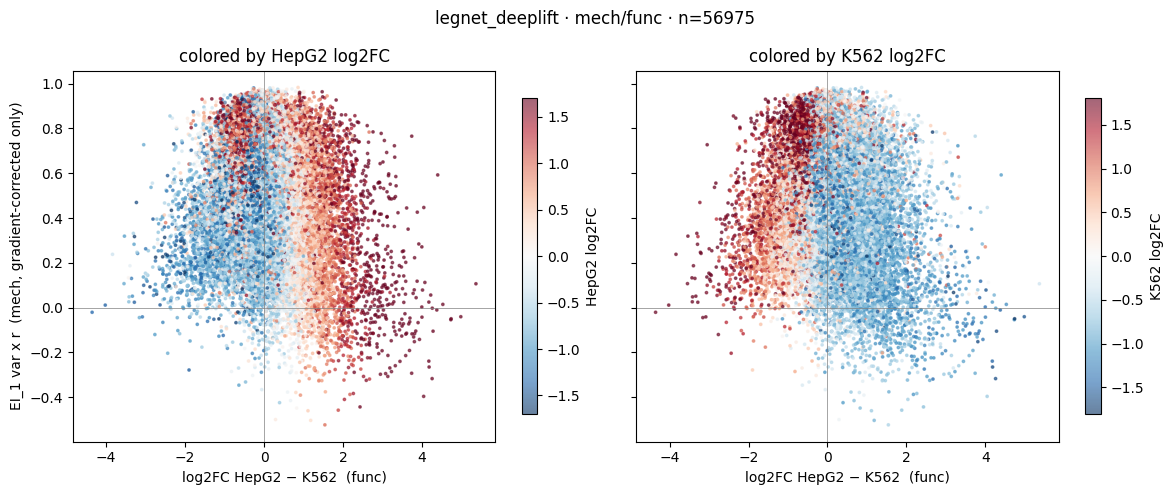

In [106]:
# Per-cell-line seqlets + mech/func scatters.
# mech axis: EigenMaps EI_1 var x r on gradient-corrected importance (no z-norm).
import sys
sys.path.insert(0, '/grid/koo/home/pmantill/projects/kcee-ui')
import matplotlib.pyplot as plt
from tangermeme.utils import one_hot_encode
from kcee_ui.scoring import attr_to_importance

SRC = 'legnet_deeplift'
A_hep = attr[(SRC, 'HepG2')].astype(np.float32)               # (N, 4, 200) hypothetical
A_k   = attr[(SRC, 'K562')].astype(np.float32)
N, _, L = A_hep.shape

# Var-region one-hot via tangermeme (var = sequence[15:215] within 230bp insert).
onehot = np.stack([
    one_hot_encode(s[15:15 + L]).numpy().astype(np.float32)
    for s in library['sequence'].to_numpy()
])                                                            # (N, 4, L)

# Importance = WT-projected, gradient-corrected hypothetical attribution → (N, L).
imp_hep = attr_to_importance(A_hep, onehot)
imp_k   = attr_to_importance(A_k,   onehot)

seqlets_hep = recursive_seqlets(imp_hep)
seqlets_k   = recursive_seqlets(imp_k)
print('seqlets HepG2:', len(seqlets_hep), '| K562:', len(seqlets_k))

# EI_1 var x r: batched 2x2 eigendecomp on raw importance (no z-norm, no centering).
E = np.stack([imp_hep, imp_k], axis=-1).astype(np.float64)    # (N, L, 2)
C = np.einsum('nlk,nlj->nkj', E, E) / L                       # (N, 2, 2)
eigvals = np.linalg.eigvalsh(C)[:, ::-1]                      # descending
var_ratio = eigvals[:, 0] / eigvals.sum(1)
r_corr = C[:, 0, 1] / np.sqrt(C[:, 0, 0] * C[:, 1, 1])
ei1_var_r = (var_ratio * r_corr).astype(np.float32)

hep_act = library['HepG2_log2FC'].to_numpy(np.float32)
k_act   = library['K562_log2FC'].to_numpy(np.float32)
log2fc_diff = hep_act - k_act

ok = np.isfinite(ei1_var_r) & np.isfinite(log2fc_diff)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, c_arr, label in [(axes[0], hep_act, 'HepG2 log2FC'),
                          (axes[1], k_act,   'K562 log2FC')]:
    cc = c_arr[ok]
    vmax = float(np.nanpercentile(np.abs(cc), 98))
    sc = ax.scatter(log2fc_diff[ok], ei1_var_r[ok], c=cc, cmap='RdBu_r',
                    vmin=-vmax, vmax=vmax, s=3, alpha=0.6)
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
    ax.set(xlabel='log2FC HepG2 − K562  (func)',
           title=f'colored by {label}')
    fig.colorbar(sc, ax=ax, shrink=0.85, label=label)
axes[0].set_ylabel('EI_1 var x r  (mech, gradient-corrected only)')
fig.suptitle(f'{SRC} · mech/func · n={int(ok.sum())}')
plt.tight_layout()


seqlets HepG2: 64330 | K562: 62301


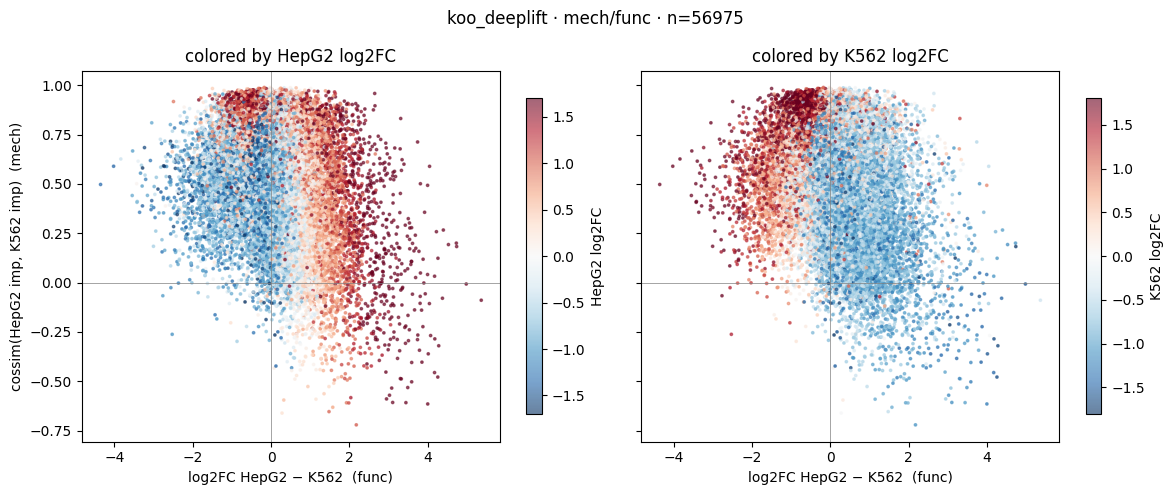

In [107]:
# Per-cell-line seqlets + mech/func scatters (colored by each cell line's log2FC).
# mech = plain cosine similarity (NO z-score) between HepG2 and K562 importance.
import sys
sys.path.insert(0, '/grid/koo/home/pmantill/projects/kcee-ui')
import matplotlib.pyplot as plt
from tangermeme.utils import one_hot_encode
from kcee_ui.scoring import attr_to_importance

SRC = 'koo_deeplift'
A_hep = attr[(SRC, 'HepG2')].astype(np.float32)               # (N, 4, 200) hypothetical
A_k   = attr[(SRC, 'K562')].astype(np.float32)
N, _, L = A_hep.shape

# Var-region one-hot via tangermeme (var = sequence[15:215] within 230bp insert).
onehot = np.stack([
    one_hot_encode(s[15:15 + L]).numpy().astype(np.float32)
    for s in library['sequence'].to_numpy()
])                                                            # (N, 4, L)

# Importance = WT-projected hypothetical attribution → (N, L).
imp_hep = attr_to_importance(A_hep, onehot)
imp_k   = attr_to_importance(A_k,   onehot)

# Seqlets: separate calls per cell line, on the L-vectors.
seqlets_hep = recursive_seqlets(imp_hep)
seqlets_k   = recursive_seqlets(imp_k)
print('seqlets HepG2:', len(seqlets_hep), '| K562:', len(seqlets_k))

# mech: plain per-row cossim on raw importance (no z-norm).
cossim = (imp_hep * imp_k).sum(1) / np.maximum(
    np.linalg.norm(imp_hep, axis=1) * np.linalg.norm(imp_k, axis=1), 1e-12)

# func: measured log2FC(HepG2) − log2FC(K562); also per-CT activity for color.
hep_act = library['HepG2_log2FC'].to_numpy(np.float32)
k_act   = library['K562_log2FC'].to_numpy(np.float32)
log2fc_diff = hep_act - k_act

ok = np.isfinite(cossim) & np.isfinite(log2fc_diff)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, c_arr, label in [(axes[0], hep_act, 'HepG2 log2FC'),
                          (axes[1], k_act,   'K562 log2FC')]:
    cc = c_arr[ok]
    vmax = float(np.nanpercentile(np.abs(cc), 98))
    sc = ax.scatter(log2fc_diff[ok], cossim[ok], c=cc, cmap='RdBu_r',
                    vmin=-vmax, vmax=vmax, s=3, alpha=0.6)
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
    ax.set(xlabel='log2FC HepG2 − K562  (func)',
           title=f'colored by {label}')
    fig.colorbar(sc, ax=ax, shrink=0.85, label=label)
axes[0].set_ylabel('cossim(HepG2 imp, K562 imp)  (mech)')
fig.suptitle(f'{SRC} · mech/func · n={int(ok.sum())}')
plt.tight_layout()


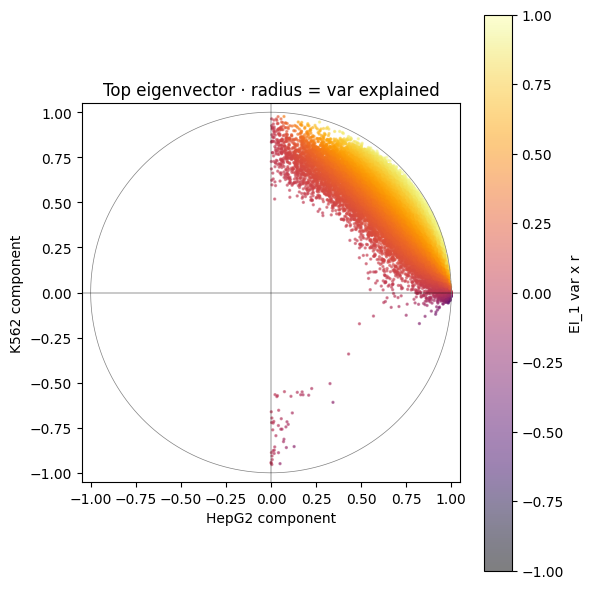

In [108]:
# Top eigenvector per sample, length = variance explained, in (HepG2, K562).
eigvals_full, eigvecs = np.linalg.eigh(C)              # ascending; (N, 2), (N, 2, 2)
total_var = eigvals_full.sum(1)
vr1 = eigvals_full[:, -1] / total_var                  # top var ratio (0.5..1)
vr2 = eigvals_full[:,  0] / total_var                  # bottom var ratio (0..0.5)

v1 = eigvecs[:, :, -1] * np.sign(eigvecs[:, :1, -1] + 1e-12)
v1_scaled = v1 * vr1[:, None]

theta = np.linspace(0, 2 * np.pi, 200)
plt.figure(figsize=(6, 6))
plt.plot(np.cos(theta), np.sin(theta), color='gray', lw=0.5)
sc = plt.scatter(v1_scaled[:, 0], v1_scaled[:, 1], c=ei1_var_r, cmap='inferno',
                 s=2, alpha=0.5, vmin=-1, vmax=1)
plt.colorbar(sc, label='EI_1 var x r')
plt.axhline(0, color='k', lw=0.3); plt.axvline(0, color='k', lw=0.3)
plt.gca().set_aspect('equal'); plt.xlim(-1.05, 1.05); plt.ylim(-1.05, 1.05)
plt.xlabel('HepG2 component'); plt.ylabel('K562 component')
plt.title('Top eigenvector · radius = var explained')
plt.tight_layout()


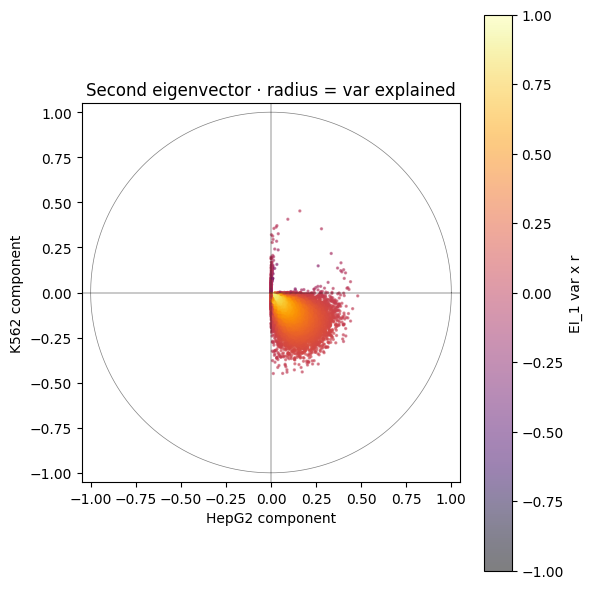

In [109]:
# Second eigenvector per sample, length = variance explained, in (HepG2, K562).
v2 = eigvecs[:, :, 0] * np.sign(eigvecs[:, :1, 0] + 1e-12)
v2_scaled = v2 * vr2[:, None]

plt.figure(figsize=(6, 6))
plt.plot(np.cos(theta), np.sin(theta), color='gray', lw=0.5)
sc = plt.scatter(v2_scaled[:, 0], v2_scaled[:, 1], c=ei1_var_r, cmap='inferno',
                 s=2, alpha=0.5, vmin=-1, vmax=1)
plt.colorbar(sc, label='EI_1 var x r')
plt.axhline(0, color='k', lw=0.3); plt.axvline(0, color='k', lw=0.3)
plt.gca().set_aspect('equal'); plt.xlim(-1.05, 1.05); plt.ylim(-1.05, 1.05)
plt.xlabel('HepG2 component'); plt.ylabel('K562 component')
plt.title('Second eigenvector · radius = var explained')
plt.tight_layout()


rank 10 → seq 4475: EI_1 var x r=+0.974  EI_1=[hep:+0.86, k562:+0.51]  EI_2=[hep:+0.51, k562:-0.86]  EI_1 var=99.3%


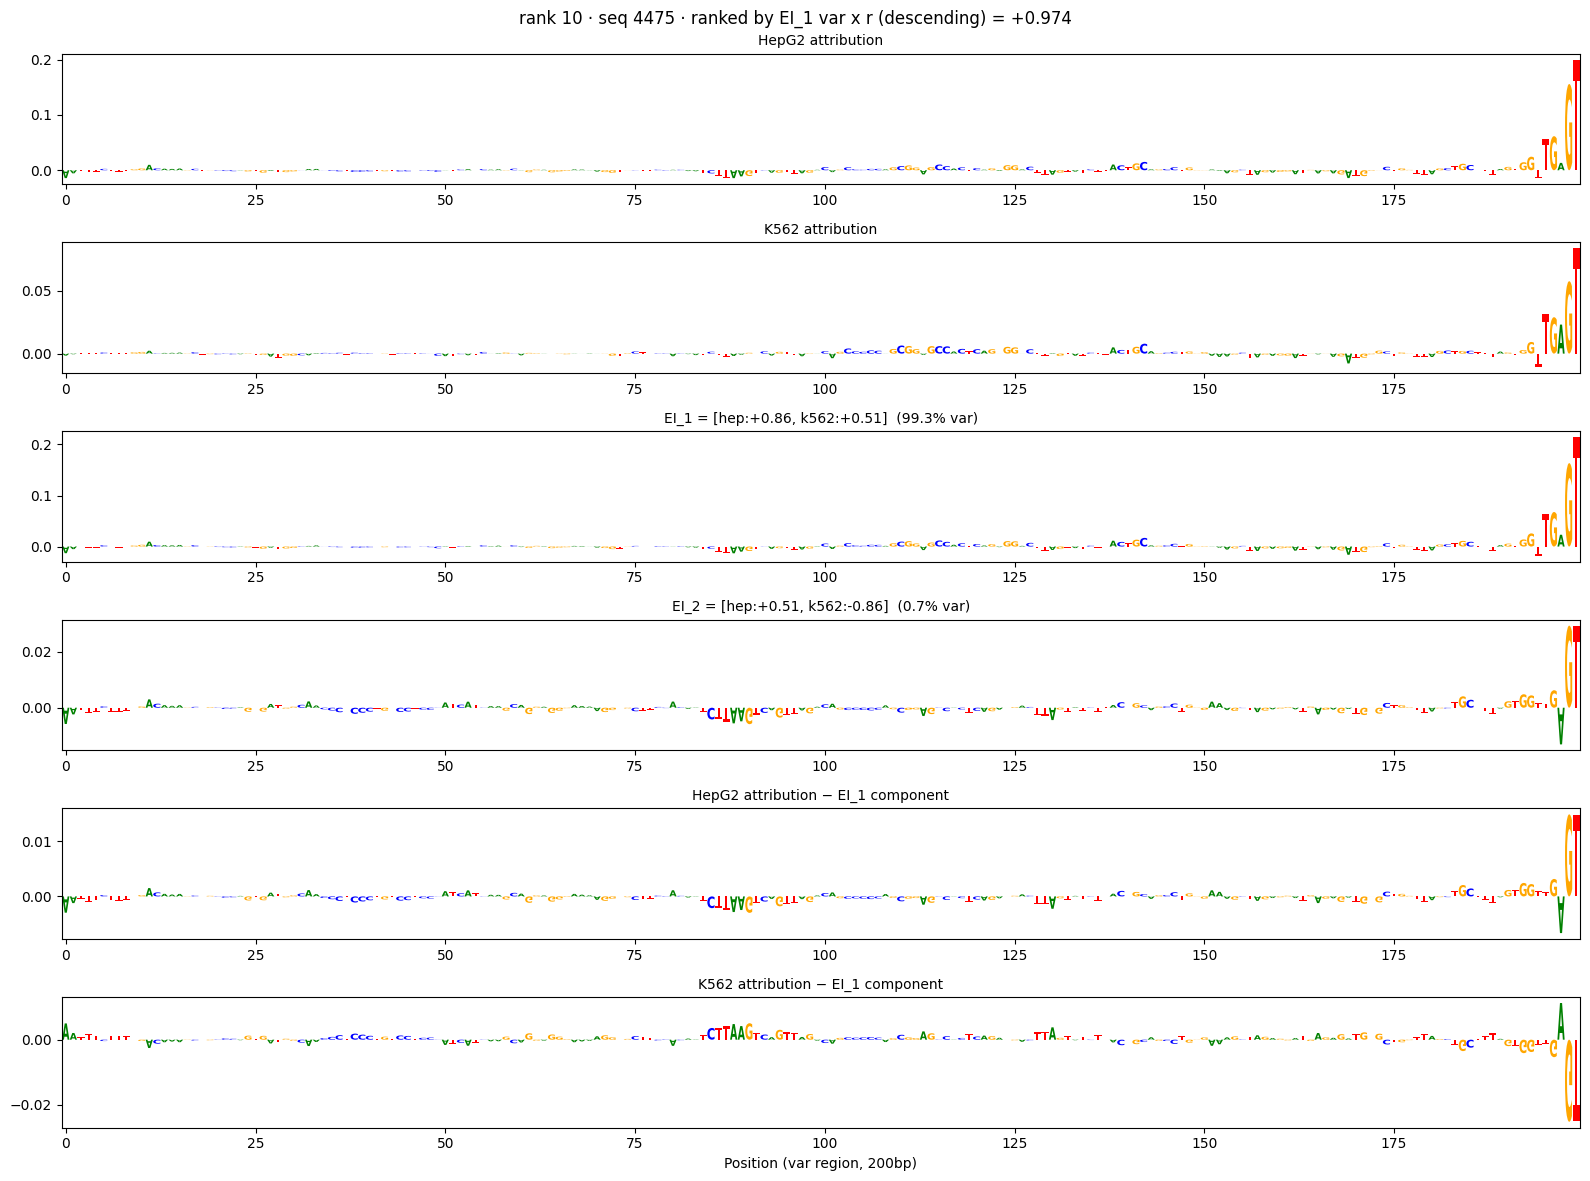

In [121]:
# Per-CT attribution logos + both eigen-logos + EI_1-residual per-CT logos.
# Ranked by EI_1 var x r (var_ratio * Pearson r), descending.
sys.path.insert(0, '/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/'
                   'Hippo_dependency_mpra/eigen-interactions')
from fast_logo import fast_logo

RANK = 10
ranked = np.argsort(-ei1_var_r)                        # descending EI_1 var x r
idx = int(ranked[RANK])

ev1 = v1[idx]
ev2 = eigvecs[idx, :, 0] * np.sign(eigvecs[idx, 0, 0] + 1e-12)
print(f'rank {RANK} → seq {idx}: '
      f'EI_1 var x r={ei1_var_r[idx]:+.3f}  '
      f'EI_1=[hep:{ev1[0]:+.2f}, k562:{ev1[1]:+.2f}]  '
      f'EI_2=[hep:{ev2[0]:+.2f}, k562:{ev2[1]:+.2f}]  '
      f'EI_1 var={vr1[idx]:.1%}')

actual_hep = A_hep[idx] * onehot[idx]                  # (4, L)
actual_k   = A_k[idx]   * onehot[idx]
logo_ei1 = ev1[0] * actual_hep + ev1[1] * actual_k     # scalar coord along unit ev1
logo_ei2 = ev2[0] * actual_hep + ev2[1] * actual_k

resid_hep = actual_hep - logo_ei1 * ev1[0]
resid_k   = actual_k   - logo_ei1 * ev1[1]

logos_and_titles = [
    (actual_hep, 'HepG2 attribution'),
    (actual_k,   'K562 attribution'),
    (logo_ei1,   f'EI_1 = [hep:{ev1[0]:+.2f}, k562:{ev1[1]:+.2f}]  ({vr1[idx]:.1%} var)'),
    (logo_ei2,   f'EI_2 = [hep:{ev2[0]:+.2f}, k562:{ev2[1]:+.2f}]  ({vr2[idx]:.1%} var)'),
    (resid_hep,  'HepG2 attribution − EI_1 component'),
    (resid_k,    'K562 attribution − EI_1 component'),
]

fig, axes = plt.subplots(6, 1, figsize=(16, 12))
for ax, (lg, t) in zip(axes, logos_and_titles):
    fast_logo(lg, ax=ax)
    ax.set_title(t, fontsize=10)
axes[-1].set_xlabel('Position (var region, 200bp)')
fig.suptitle(f'rank {RANK} · seq {idx} · ranked by EI_1 var x r (descending) = {ei1_var_r[idx]:+.3f}')
plt.tight_layout()


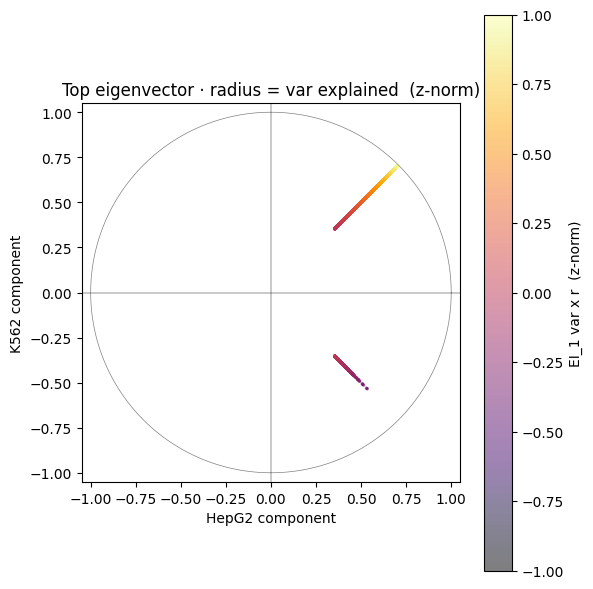

In [111]:
# --- Z-NORM VARIANT --- mirror of the no-z-norm pipeline.
# Per-sample mean-center + std-divide each CT vector (matches eigen-interactions
# `eigendecompose` preprocessing, eigen_steering.py:786-790).
mu = E.mean(axis=1, keepdims=True)
sd = E.std(axis=1, keepdims=True)
E_z = (E - mu) / np.where(sd > 0, sd, 1.0)
C_z = np.einsum('nlk,nlj->nkj', E_z, E_z) / L
eigvals_full_z, eigvecs_z = np.linalg.eigh(C_z)
total_var_z = eigvals_full_z.sum(1)
vr1_z = eigvals_full_z[:, -1] / total_var_z
vr2_z = eigvals_full_z[:,  0] / total_var_z
r_corr_z   = C_z[:, 0, 1] / np.sqrt(C_z[:, 0, 0] * C_z[:, 1, 1])
ei1_var_r_z = (vr1_z * r_corr_z).astype(np.float32)

v1_z = eigvecs_z[:, :, -1] * np.sign(eigvecs_z[:, :1, -1] + 1e-12)
v1_scaled_z = v1_z * vr1_z[:, None]

plt.figure(figsize=(6, 6))
plt.plot(np.cos(theta), np.sin(theta), color='gray', lw=0.5)
sc = plt.scatter(v1_scaled_z[:, 0], v1_scaled_z[:, 1], c=ei1_var_r_z,
                 cmap='inferno', s=2, alpha=0.5, vmin=-1, vmax=1)
plt.colorbar(sc, label='EI_1 var x r  (z-norm)')
plt.axhline(0, color='k', lw=0.3); plt.axvline(0, color='k', lw=0.3)
plt.gca().set_aspect('equal'); plt.xlim(-1.05, 1.05); plt.ylim(-1.05, 1.05)
plt.xlabel('HepG2 component'); plt.ylabel('K562 component')
plt.title('Top eigenvector · radius = var explained  (z-norm)')
plt.tight_layout()


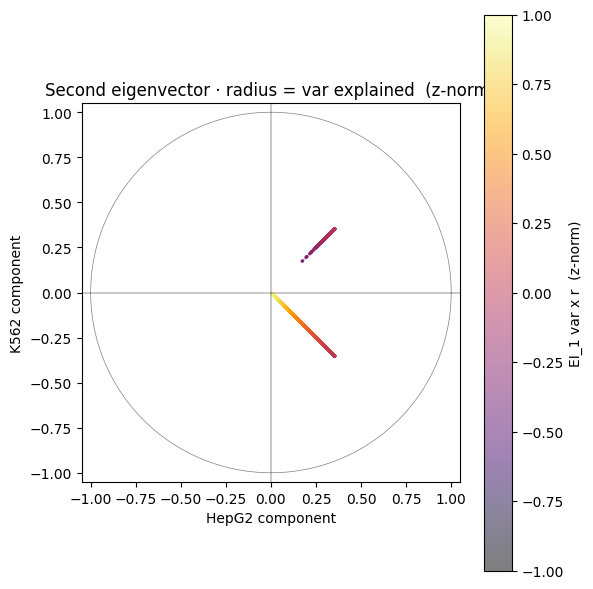

In [112]:
# Second eigenvector (z-norm), length = variance explained.
v2_z = eigvecs_z[:, :, 0] * np.sign(eigvecs_z[:, :1, 0] + 1e-12)
v2_scaled_z = v2_z * vr2_z[:, None]

plt.figure(figsize=(6, 6))
plt.plot(np.cos(theta), np.sin(theta), color='gray', lw=0.5)
sc = plt.scatter(v2_scaled_z[:, 0], v2_scaled_z[:, 1], c=ei1_var_r_z,
                 cmap='inferno', s=2, alpha=0.5, vmin=-1, vmax=1)
plt.colorbar(sc, label='EI_1 var x r  (z-norm)')
plt.axhline(0, color='k', lw=0.3); plt.axvline(0, color='k', lw=0.3)
plt.gca().set_aspect('equal'); plt.xlim(-1.05, 1.05); plt.ylim(-1.05, 1.05)
plt.xlabel('HepG2 component'); plt.ylabel('K562 component')
plt.title('Second eigenvector · radius = var explained  (z-norm)')
plt.tight_layout()


rank 10 → seq 5152: EI_1 var x r (z-norm)=+0.969  EI_1=[hep:+0.71, k562:+0.71]  EI_2=[hep:+0.71, k562:-0.71]  EI_1 var=99.0%


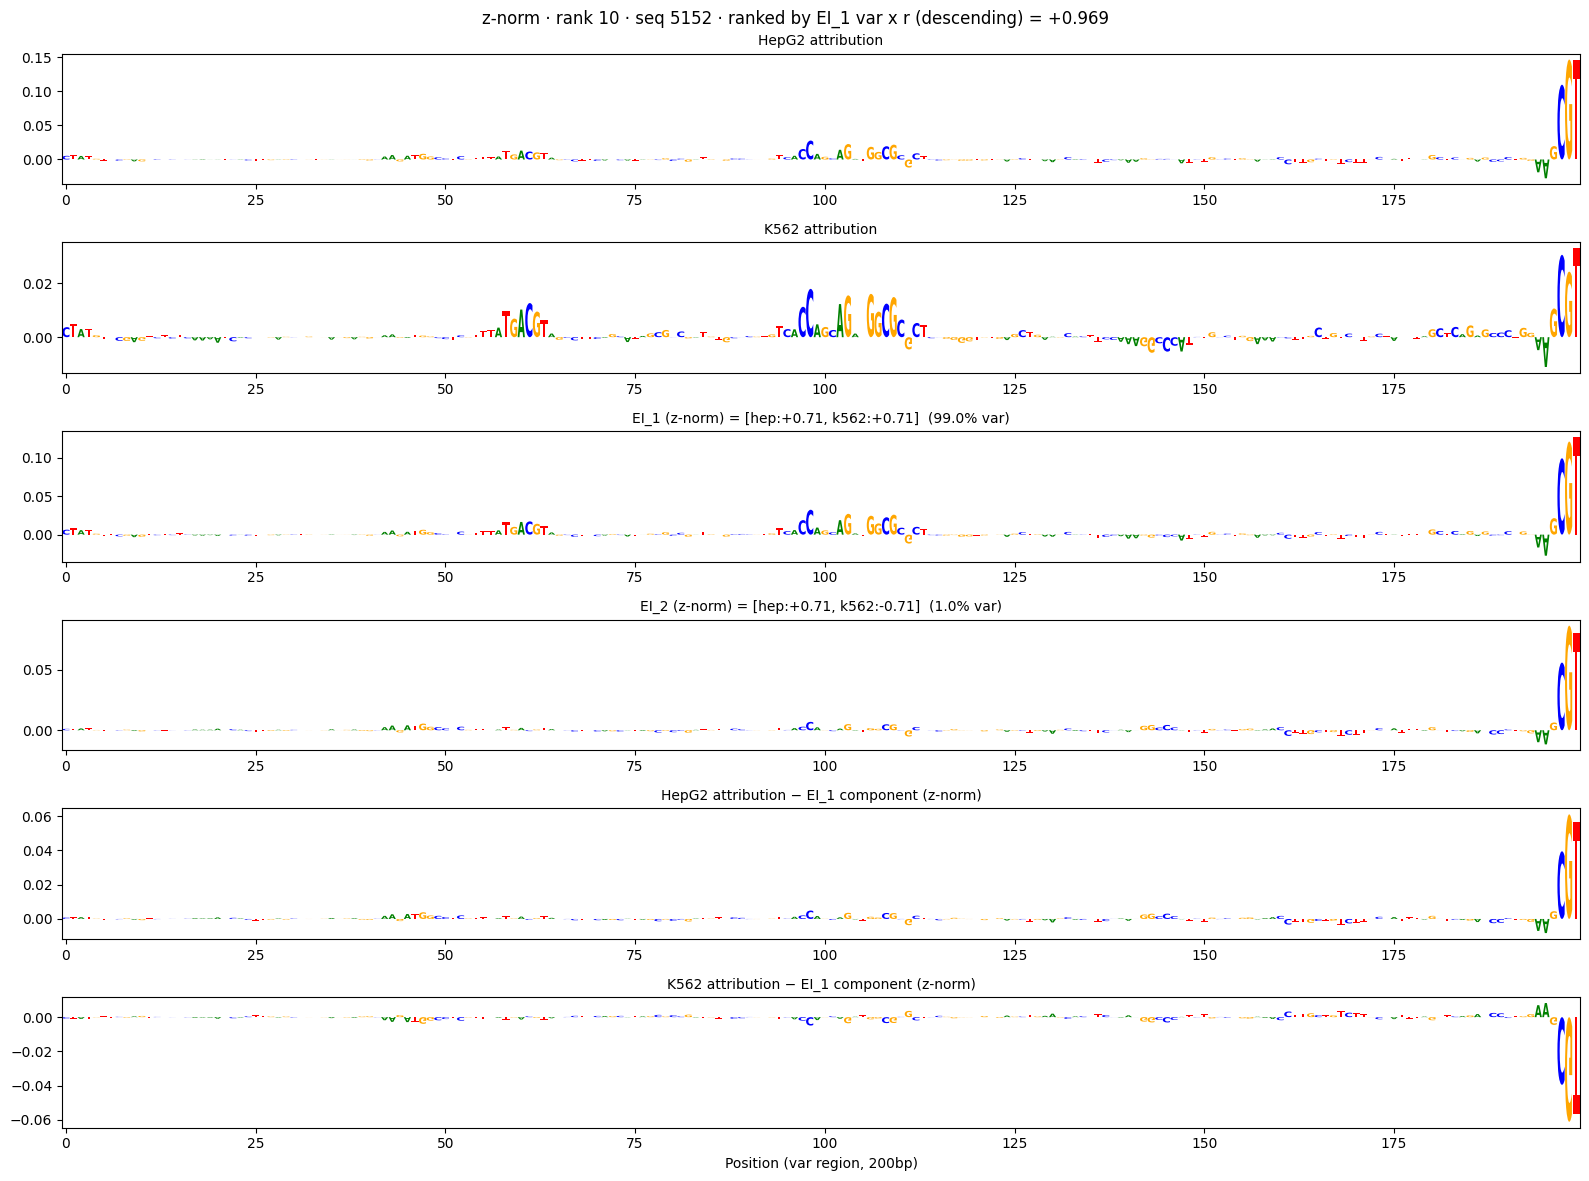

In [122]:
# Per-CT logos + both eigen-logos (z-norm) + EI_1-residual per-CT logos.
# Ranked by EI_1 var x r (z-norm), descending. Bump RANK_Z to step through.
RANK_Z = 10
ranked_z = np.argsort(-ei1_var_r_z)
idx_z = int(ranked_z[RANK_Z])

ev1_z = v1_z[idx_z]
ev2_z = eigvecs_z[idx_z, :, 0] * np.sign(eigvecs_z[idx_z, 0, 0] + 1e-12)
print(f'rank {RANK_Z} → seq {idx_z}: '
      f'EI_1 var x r (z-norm)={ei1_var_r_z[idx_z]:+.3f}  '
      f'EI_1=[hep:{ev1_z[0]:+.2f}, k562:{ev1_z[1]:+.2f}]  '
      f'EI_2=[hep:{ev2_z[0]:+.2f}, k562:{ev2_z[1]:+.2f}]  '
      f'EI_1 var={vr1_z[idx_z]:.1%}')

actual_hep_z = A_hep[idx_z] * onehot[idx_z]
actual_k_z   = A_k[idx_z]   * onehot[idx_z]
logo_ei1_z = ev1_z[0] * actual_hep_z + ev1_z[1] * actual_k_z
logo_ei2_z = ev2_z[0] * actual_hep_z + ev2_z[1] * actual_k_z

resid_hep_z = actual_hep_z - logo_ei1_z * ev1_z[0]
resid_k_z   = actual_k_z   - logo_ei1_z * ev1_z[1]

logos_and_titles_z = [
    (actual_hep_z, 'HepG2 attribution'),
    (actual_k_z,   'K562 attribution'),
    (logo_ei1_z,   f'EI_1 (z-norm) = [hep:{ev1_z[0]:+.2f}, k562:{ev1_z[1]:+.2f}]  ({vr1_z[idx_z]:.1%} var)'),
    (logo_ei2_z,   f'EI_2 (z-norm) = [hep:{ev2_z[0]:+.2f}, k562:{ev2_z[1]:+.2f}]  ({vr2_z[idx_z]:.1%} var)'),
    (resid_hep_z,  'HepG2 attribution − EI_1 component (z-norm)'),
    (resid_k_z,    'K562 attribution − EI_1 component (z-norm)'),
]

fig, axes = plt.subplots(6, 1, figsize=(16, 12))
for ax, (lg, t) in zip(axes, logos_and_titles_z):
    fast_logo(lg, ax=ax)
    ax.set_title(t, fontsize=10)
axes[-1].set_xlabel('Position (var region, 200bp)')
fig.suptitle(f'z-norm · rank {RANK_Z} · seq {idx_z} · ranked by EI_1 var x r (descending) = {ei1_var_r_z[idx_z]:+.3f}')
plt.tight_layout()
